### 1. Loading Data and Visualizing Word Count Distribution

In this section, we perform the following:

1. **Data Loading**: We load the dataset containing Amazon product reviews from a CSV file for analysis.
2. **Histogram Plotting**: We define a function to visualize the distribution of word counts in the reviews by plotting a histogram. This will help us understand the variability in review lengths.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


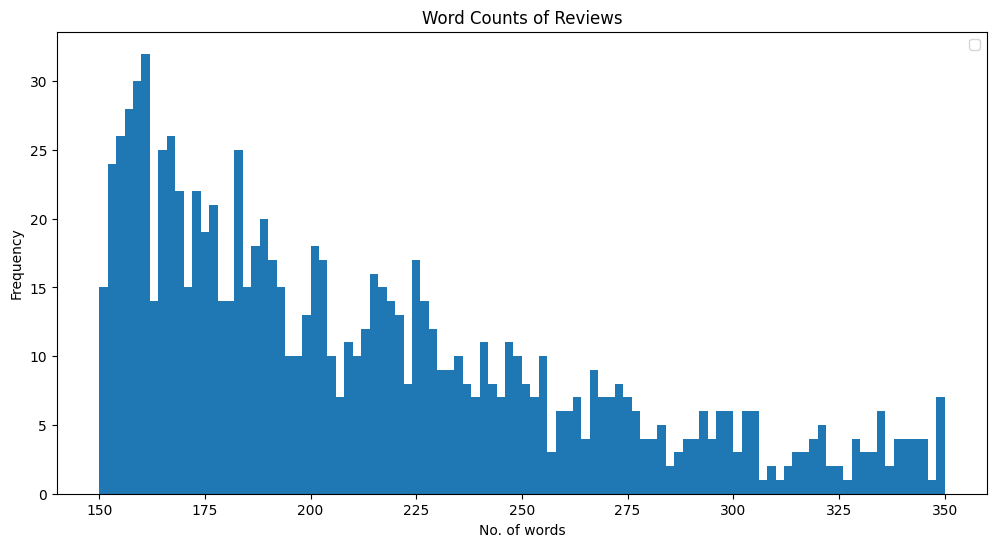

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("./Input/input.csv")

def plot_histogram(word_counts):
    plt.figure(figsize=(12,6))
    plt.hist(word_counts, bins = 100)
    plt.title("Word Counts of Reviews")
    plt.xlabel("No. of words")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()
    
plot_histogram(df["Words"].tolist())

### 2. Summarizing an Example Review Using Pretrained Models

In this section, we perform the following steps:

1. **Dataset Creation**: We create a dataset from a pandas DataFrame containing product reviews using the `datasets` library.
2. **Select a Sample Review**: We extract the first review from the dataset for summarization.
3. **Summarization with PEGASUS**: 
   - We initialize a summarization pipeline using the `google/pegasus-cnn_dailymail` model.
   - The original review is displayed, followed by its summarized output.
4. **Summarization with T5**: 
   - We set up another summarization pipeline using the `t5-large` model.
   - The original review is summarized, and the output is displayed.
5. **Summarization with BART**: 
   - Finally, we use the `facebook/bart-large-cnn` model to summarize the original review.
   - The summarized text is printed.

In [9]:
width = 100
from datasets import Dataset
dataset = Dataset.from_pandas(df)
sample_text = dataset["Review"][0]

In [10]:
print("#################### Original Review ####################".center(width))
print(sample_text)
from transformers import pipeline, set_seed
set_seed(42)

                     #################### Original Review ####################                      
So I've been a pretty big fan of Amazon stuff for sometime. I use Amazon Basics stuff whenever I can. I also rarely leave reviews.But this thing was a big enough disappointment and continues to be a frustration that I figured people need to know some stuff.First off, as an Alexa device, it's fine. Plays music, does the 4 other things Alexa is able to do (different rant).But one of the main reasons I got this thing wasn't for Alexa or as just a music player, I wanted to make a 2-studio-1-subwoofer home theater.Well it really sucks at that so far. Connecting using the Alexa app is fairly simple, but it just refuses to be a reliable home theater system. It constantly drops sound, or has intermittent sound loss. Happens randomly. Sometimes I'll just turn on the TV and only the sub will be working. So I'll have to recreate the entire home theater system. It's also really picky about what it 

In [18]:
from transformers import pipeline, set_seed

# Set seed for reproducibility
set_seed(42)

def summarize_text(sample_text, model_name, model_name_plain, special_handling=False, width=100,):
    # Initialize the pipeline with the given model
    pipe = pipeline("summarization", model=model_name, device=0)
    # Generate summary
    pipe_out = pipe(sample_text)
    summary = pipe_out[0]["summary_text"]
    
    # Special handling for PEGASUS model
    if special_handling:
        summary = summary.replace(" .<n>", ".")
    
    # Print the summary
    print(f"#################### Summary: {model_name_plain} ####################".center(width))
    print(summary)


# Print the original review
width = 100  # Adjust the width for centering
print("#################### Original Review ####################".center(width))
print(sample_text)

# Summarize using PEGASUS with special handling
summarize_text(sample_text, "google/pegasus-cnn_dailymail", "PEGASUS", special_handling=True)

# Summarize using T5
summarize_text(sample_text, "t5-large", "T5")

# Summarize using BART
summarize_text(sample_text, "facebook/bart-large-cnn", "BART")


                     #################### Original Review ####################                      
So I've been a pretty big fan of Amazon stuff for sometime. I use Amazon Basics stuff whenever I can. I also rarely leave reviews.But this thing was a big enough disappointment and continues to be a frustration that I figured people need to know some stuff.First off, as an Alexa device, it's fine. Plays music, does the 4 other things Alexa is able to do (different rant).But one of the main reasons I got this thing wasn't for Alexa or as just a music player, I wanted to make a 2-studio-1-subwoofer home theater.Well it really sucks at that so far. Connecting using the Alexa app is fairly simple, but it just refuses to be a reliable home theater system. It constantly drops sound, or has intermittent sound loss. Happens randomly. Sometimes I'll just turn on the TV and only the sub will be working. So I'll have to recreate the entire home theater system. It's also really picky about what it 

Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at google/pegasus-cnn_dailymail and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


                     #################### Summary: PEGASUS ####################                     
Connecting using the Alexa app is fairly simple, but it just refuses to be a reliable home theater system.It constantly drops sound, or has intermittent sound loss. Happens randomly. Sometimes I'll just turn on the TV and only the sub will be working.If you're looking for a better sound quality home theater than a priced sound barsub combo will probably beat whatever studiosub combo (dollar to dollar)
                       #################### Summary: T5 ####################                        
studiossub is a 2-studio-1-subwoofer home theater system . it's picky about what it will and won't work with . if you want a better sound quality home theater than a comparably priced sound barsub will probably beat this .
                      #################### Summary: BART ####################                       
As an Alexa device, it's fine. Plays music, does the 4 other things A


## 3. Text Summarization with Transformer Models


- **Imports**:
  - `tqdm`: For progress bar visualization.
  - `torch`: To handle tensors and check for available CUDA devices.
  - `AutoModelForSeq2SeqLM` and `AutoTokenizer`: To load pre-trained models and tokenizers from Hugging Face.

- **Device Setup**:
  - The code checks if a CUDA-enabled GPU is available and sets the `device` to either "cuda" or "CPU".

- **Function: `chunks`**:
  - Splits a list into smaller batches of a specified size.
  - Takes `list_of_elements` and `batch_size` as arguments and yields chunks.

- **Function: `generate_summaries`**:
  - Generates text summaries for a given dataset.
  - Arguments:
    - `dataset`: Input dataset containing text to summarize.
    - `model` and `tokenizer`: Pretrained transformer model and tokenizer.
    - `batch_size`: Size of batches for processing.
    - `device`: Device for computation (GPU or CPU).
    - `column_text`: Name of the column in the dataset containing the text.
    - `model_type`: Model-specific flag for special handling (e.g., PEGASUS).
  - Steps:
    1. Splits the dataset into batches.
    2. Tokenizes the input data.
    3. Generates summaries using the model with beam search (`num_beams=8`).
    4. Decodes the generated summaries.
    5. If `model_type` is "pegasus", replaces PEGASUS-specific tokens (`<n>`) with spaces.
  - Returns a list of summaries.

- **Usage**:
  - This function can handle different transformer models and adjust for model-specific behavior, like PEGASUS's special token handling.

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [9]:
def chunks(list_of_elements, batch_size):
    """Yield successive batch-sized chunks from list_of_elements."""
    for i in range(0, len(list_of_elements), batch_size):
        yield list_of_elements[i : i + batch_size]

In [27]:
def generate_summaries(dataset, model, tokenizer, batch_size=16, device=device, column_text="Review", model_type="generic"):
    review_batches = list(chunks(dataset[column_text], batch_size))
    s = []
    for review_batch in tqdm(review_batches, total=len(review_batches)):
        inputs = tokenizer(review_batch, max_length=1024, truncation=True,
                           padding="max_length", return_tensors="pt")
        summaries = model.generate(input_ids=inputs["input_ids"].to(device),
                                   attention_mask=inputs["attention_mask"].to(device), 
                                   length_penalty=0.8, num_beams=8, max_length=128)
        decoded_summaries = [tokenizer.decode(s, skip_special_tokens=True, 
                                              clean_up_tokenization_spaces=True) 
                             for s in summaries]
        
        # Special token replacement for PEGASUS
        if model_type.lower() == "pegasus":
            decoded_summaries = [d.replace("<n>", " ") for d in decoded_summaries]
        
        s.append(decoded_summaries)
    return s

## 4. Loading Pretrained Models for Text Summarization

This code demonstrates how to load and use different pretrained transformer models for summarization using the Hugging Face `transformers` library. The code sequentially loads three different models (PEGASUS, BART, and T5) and generates summaries for a given dataset.

### Steps

1. **Define Model Checkpoints**:
   - For each model (PEGASUS, BART, and T5), specify the model checkpoint (`model_ckpt`) from Hugging Face's model hub.

2. **Initialize Tokenizer and Model**:
   - Use the `AutoTokenizer` and `AutoModelForSeq2SeqLM` classes to load the pretrained tokenizer and model for each respective checkpoint.
   - Move the model to the appropriate device (GPU or CPU).

3. **Generate Summaries**:
   - For PEGASUS, use the `summaries_pegasus` function with `model_type="pegasus"` for specific token handling.
   - For BART, use the `summaries_bart` function.
   - For T5, load the model and tokenizer and generate summaries.

In [8]:
model_ckpt = "google/pegasus-cnn_dailymail"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = AutoModelForSeq2SeqLM.from_pretrained(model_ckpt).to(device)

/home/taufiq/anaconda3/lib/python3.9/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at google/pegasus-cnn_dailymail and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [19]:
s_pegasus = generate_summaries(dataset, model, tokenizer, batch_size=1, model_type="pegasus")

100%|███████████████████████████████████████████| 1000/1000 [22:53<00:00,  1.37s/it]


In [23]:
model_ckpt = "facebook/bart-large-cnn"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = AutoModelForSeq2SeqLM.from_pretrained(model_ckpt).to(device)

/home/taufiq/anaconda3/lib/python3.9/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [26]:
s_bart = generate_summaries(dataset, model, tokenizer, batch_size=1)

100%|███████████████████████████████████████████| 1000/1000 [22:34<00:00,  1.35s/it]


In [6]:
model_ckpt = "t5-large"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = AutoModelForSeq2SeqLM.from_pretrained(model_ckpt).to(device)

/home/taufiq/anaconda3/lib/python3.9/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [10]:
s_t5 = generate_summaries(dataset, model, tokenizer, batch_size=1)

100%|███████████████████████████████████████████| 1000/1000 [52:29<00:00,  3.15s/it]


## 5. Flattening Summaries and Saving to CSV

1. **Function: `get_flat_list`**:
   - A utility function that flattens a nested list (list of lists) into a single list.
   - **Arguments**:
     - `nested_list`: A nested list of summaries.
   - **Returns**:
     - A flattened list containing all individual elements from the nested lists.

2. **Flattening Summaries**:
   - The generated summaries from PEGASUS, BART, and T5 models (`s_pegasus`, `s_bart`, `s_t5`) are nested lists.
   - The `get_flat_list` function is used to flatten these lists into a single list for each model:
     - `flat_pegasus`, `flat_bart`, and `flat_t5`.

3. **Adding Summaries to DataFrame**:
   - The flattened lists are added as new columns in a Pandas DataFrame (`df`):
     - `S_pegasus`: Summaries generated by PEGASUS.
     - `S_bart`: Summaries generated by BART.
     - `S_t5`: Summaries generated by T5.

4. **Exporting to CSV**:
   - The DataFrame is saved as a CSV file at the specified path (`./Output/summaries.csv`).

In [ ]:
def get_flat_list(nested_list):
    flat_list = [item for sublist in nested_list for item in sublist]
    return flat_list

flat_pegasus = get_flat_list(s_pegasus)
flat_bart = get_flat_list(s_bart)
flat_t5 = get_flat_list(s_t5)

df["S_pegasus"] = flat_pegasus
df["S_bart"] = flat_bart
df["S_t5"] = flat_t5

df.to_csv("./Output/summaries.csv")

## 6. Calculating BERTScore for Generated Summaries and Adding to DataFrame

1. **Loading the Data**:
   - The dataset with original reviews and generated summaries (from PEGASUS, BART, T5) is loaded from a CSV file (`summaries.csv`) into a Pandas DataFrame (`df`).

2. **Function: `calculate_bertscore`**:
   - A helper function to calculate the BERTScore for a set of summaries against the original reference text.
   - **Arguments**:
     - `df`: The DataFrame containing the reviews and summaries.
     - `reference_col`: The column name for the original reference text (reviews).
     - `summary_col`: The column name for the generated summaries.
   - **Returns**:
     - Precision (`P`), Recall (`R`), and F1 scores (`F1`) as lists, calculated using the `bert-score` library.

3. **BERTScore Calculation**:
   - BERTScore is calculated for each model's summaries (PEGASUS, BART, T5) against the original reviews using the `calculate_bertscore` function.
   - BERTScore outputs Precision, Recall, and F1 scores:
     - For **PEGASUS** summaries (`S_pegasus`), the scores are stored in `pegasus_P`, `pegasus_R`, and `pegasus_F1`.
     - For **BART** summaries (`S_bart`), the scores are stored in `bart_P`, `bart_R`, and `bart_F1`.
     - For **T5** summaries (`S_t5`), the scores are stored in `t5_P`, `t5_R`, and `t5_F1`.

4. **Storing BERTScore in DataFrame**:
   - The F1 scores for PEGASUS, BART, and T5 are added as new columns in the DataFrame:
     - `pegasus_bert_F1`: F1 scores for PEGASUS.
     - `bart_bert_F1`: F1 scores for BART.
     - `t5_bert_F1`: F1 scores for T5.

5. **Displaying the Scores**:
   - The DataFrame is printed with only the columns containing BERT F1 scores for each model, allowing for a comparison of summarization performance across models.

In [17]:
df = pd.read_csv("./Output/summaries.csv")

In [19]:
from bert_score import score

# Assuming df is your dataframe with the relevant columns
# df = pd.read_csv("your_dataframe.csv")  # Load your dataframe if needed

# Function to calculate BERTScore for summaries against the original review
def calculate_bertscore(df, reference_col, summary_col):
    references = df[reference_col].tolist()  # The original reviews
    candidates = df[summary_col].tolist()    # The generated summaries
    
    # Calculate BERTScore
    P, R, F1 = score(candidates, references, lang="en", verbose=True)
    
    # Convert torch tensors to lists
    return P.tolist(), R.tolist(), F1.tolist()

# Calculate BERTScore for PEGASUS
pegasus_P, pegasus_R, pegasus_F1 = calculate_bertscore(df, 'Review', 'S_pegasus')

# Calculate BERTScore for BART
bart_P, bart_R, bart_F1 = calculate_bertscore(df, 'Review', 'S_bart')

# Calculate BERTScore for T5
t5_P, t5_R, t5_F1 = calculate_bertscore(df, 'Review', 'S_t5')

# Add the scores back to the dataframe for comparison
df['pegasus_bert_F1'] = pegasus_F1
df['bart_bert_F1'] = bart_F1
df['t5_bert_F1'] = t5_F1

# Now you can compare the F1 scores
print(df[['pegasus_bert_F1', 'bart_bert_F1', 't5_bert_F1']])


/home/taufiq/anaconda3/lib/python3.9/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


calculating scores...
computing bert embedding.


  0%|          | 0/32 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/16 [00:00<?, ?it/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/32 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/16 [00:00<?, ?it/s]

done in 32.19 seconds, 31.06 sentences/sec
     pegasus_bert_F1  bart_bert_F1  t5_bert_F1
0           0.875074      0.891012    0.823803
1           0.906373      0.890209    0.846625
2           0.915366      0.897953    0.847385
3           0.913725      0.907226    0.812147
4           0.940987      0.919554    0.846814
..               ...           ...         ...
995         0.906922      0.908651    0.867608
996         0.907989      0.921766    0.892491
997         0.936786      0.909661    0.842074
998         0.923445      0.905437    0.820183
999         0.877959      0.869960    0.801430

[1000 rows x 3 columns]


## 7. BERT F1 Score Comparison Using Seaborn Boxplot


1. **Import Seaborn**:
   - The `seaborn` library is imported as `sns` to plot the boxplot.

2. **Plotting the Boxplot**:
   - The BERT F1 scores for PEGASUS (`pegasus_bert_F1`), BART (`bart_bert_F1`), and T5 (`t5_bert_F1`) are extracted from the DataFrame (`df`).
   - These F1 scores are passed to `sns.boxplot()` to create a boxplot for each model’s summarization performance.


In [20]:
import seaborn as sns

(0.7, 1.0)

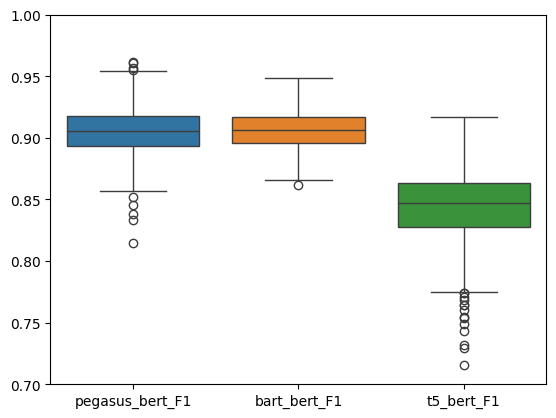

In [24]:
sns.boxplot(data=df[["pegasus_bert_F1", "bart_bert_F1", "t5_bert_F1"]])
plt.ylim(0.7, 1.0)

2025-08-25 22:58:43.701382: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1
/home/taufiq/anaconda3/envs/tensorflow/lib/python3.7/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")
Summarizing with PEGASUS: 100%|█████████████| 1000/1000 [22:59<00:00,  1.38s/it]


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Summarizing with BART: 100%|████████████████| 1000/1000 [13:21<00:00,  1.25it/s]
/home/taufiq/anaconda3/envs/tensorflow/lib/python3.7/site-packages/transformers/models/t5/tokenization_t5_fast.py:165: FutureWarning: This tokenizer was incorrectly instantiated with a model max length of 512 which will be corrected in Transformers v5.
For now, this behavior is kept to avoid breaking backwards compatibility when padding/encoding with `truncation is True`.
- Be aware that you SHOULD NOT rely on t5-large automatically truncating your input to 512 when padding/encoding.
- If you want to encode/pad to sequences longer than 512 you can either instantiate this tokenizer with `model_max_length` or pass `max_length` when encoding/padding.
- To avoid this warning, please instantiate this tokenizer with `model_max_length` set to your preferred value.
  FutureWarning,


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Summarizing with T5: 100%|██████████████████| 1000/1000 [51:45<00:00,  3.11s/it]
Some weights of the model checkpoint at roberta-large were not used when initializing RobertaModel: ['lm_head.layer_norm.bias', 'lm_head.dense.weight', 'lm_head.layer_norm.weight', 'lm_head.bias', 'lm_head.dense.bias']
- This IS expected if you are initializing RobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.weight', 'roberta.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task t

...

calculating scores...
computing bert embedding.


  0%|          | 0/32 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/16 [00:00<?, ?it/s]

done in 33.79 seconds, 29.60 sentences/sec


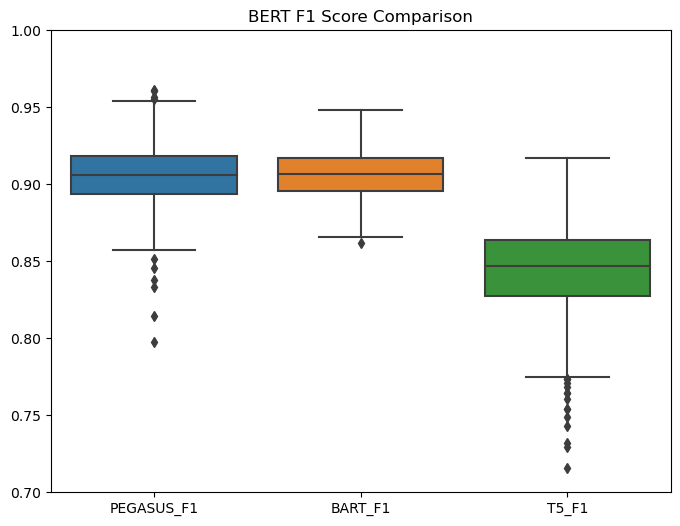

In [1]:
import mlflow
import mlflow.pytorch  # For logging PyTorch models
from transformers import pipeline, set_seed, AutoTokenizer, AutoModelForSeq2SeqLM
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from bert_score import score
from tqdm import tqdm
import torch

# ----------------------------------------
# Step 1: Load Data
# ----------------------------------------
df = pd.read_csv("./Input/input.csv")

# ----------------------------------------
# Step 2: Start an MLflow run
# ----------------------------------------
with mlflow.start_run(run_name="Text_Summarization_Experiment"):

    # Log dataset info
    mlflow.log_param("dataset_path", "./Input/input.csv")
    mlflow.log_param("num_samples", len(df))

    # ----------------------------------------
    # Step 3: Model Summarization Loop
    # ----------------------------------------
    models = {
        "PEGASUS": "google/pegasus-cnn_dailymail",
        "BART": "facebook/bart-large-cnn",
        "T5": "t5-large"
    }

    device = "cuda" if torch.cuda.is_available() else "cpu"
    batch_size = 1

    all_summaries = {}

    for model_name, checkpoint in models.items():
        # Log model parameters
        mlflow.log_param(f"{model_name}_checkpoint", checkpoint)
        mlflow.log_param(f"{model_name}_device", device)
        mlflow.log_param(f"{model_name}_batch_size", batch_size)

        # Load model and tokenizer
        tokenizer = AutoTokenizer.from_pretrained(checkpoint)
        model = AutoModelForSeq2SeqLM.from_pretrained(checkpoint).to(device)

        # Optional: log model as MLflow artifact
        mlflow.pytorch.log_model(model, artifact_path=f"models/{model_name}")

        # Generate summaries
        summaries = []
        for review in tqdm(df["Review"], desc=f"Summarizing with {model_name}"):
            inputs = tokenizer(review, max_length=1024, truncation=True,
                               padding="max_length", return_tensors="pt").to(device)
            output_ids = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                num_beams=8,
                max_length=128,
                length_penalty=0.8
            )
            decoded = tokenizer.decode(output_ids[0], skip_special_tokens=True)
            if model_name == "PEGASUS":
                decoded = decoded.replace("<n>", " ")
            summaries.append(decoded)

        # Store summaries
        all_summaries[model_name] = summaries
        df[f"S_{model_name}"] = summaries

    # ----------------------------------------
    # Step 4: Calculate BERTScore
    # ----------------------------------------
    def calculate_bertscore(df, reference_col, summary_col):
        P, R, F1 = score(df[summary_col].tolist(),
                         df[reference_col].tolist(),
                         lang="en", verbose=True)
        return P.tolist(), R.tolist(), F1.tolist()

    for model_name in models.keys():
        P, R, F1 = calculate_bertscore(df, "Review", f"S_{model_name}")
        df[f"{model_name}_P"] = P
        df[f"{model_name}_R"] = R
        df[f"{model_name}_F1"] = F1

        # Log average metrics
        mlflow.log_metric(f"{model_name}_avg_F1", sum(F1)/len(F1))
        mlflow.log_metric(f"{model_name}_avg_P", sum(P)/len(P))
        mlflow.log_metric(f"{model_name}_avg_R", sum(R)/len(R))

    # ----------------------------------------
    # Step 5: Save CSV & log as artifact
    # ----------------------------------------
    df.to_csv("./summaries.csv", index=False)
    mlflow.log_artifact("./summaries.csv")

    # ----------------------------------------
    # Step 6: Visualization
    # ----------------------------------------
    plt.figure(figsize=(8,6))
    sns.boxplot(data=df[[f"{m}_F1" for m in models.keys()]])
    plt.ylim(0.7, 1.0)
    plt.title("BERT F1 Score Comparison")
    plt.savefig("bertscore_boxplot.png")
    mlflow.log_artifact("bertscore_boxplot.png")
    plt.show()

# MLflow run ends here
